# Практика: Geopandas + OSMnx
## Загрузка кофеен Выборга

**Цель:** Научиться загружать геоданные из OpenStreetMap и работать с ними в Geopandas.

**Данные:** Все кофейни (кафе) в городе Выборг.

## Часть 1. Импорт библиотек

In [30]:
import osmnx as ox
import geopandas as gpd
import pandas as pd

print("Библиотеки загружены")

Библиотеки загружены


## Часть 2. Загрузка кофеен Выборга

In [31]:
# Координаты Выборга (центр)
vyborg_coords = (60.7127, 28.7359)

# Загружаем все точки с amenity=cafe в радиусе 2 км от центра
print("Загрузка кофеен...")

gdf = ox.features_from_point(
    center_point=vyborg_coords,
    dist=2000,
    tags={'amenity': 'cafe'}
)

# gdf = gpd.read_file('../../data/vyborg_cafes.geojson')

print(f"Найдено кофеен: {len(gdf)}")
gdf.head()

Загрузка кофеен...
Найдено кофеен: 92


geometry amenity        name  \
element id                                                          
node    1355645018  POINT (28.76162 60.70769)    cafe     Минутка   
        1483632393  POINT (28.75794 60.71133)    cafe      Чердак   
        1521384432  POINT (28.74948 60.71224)    cafe      Назаре   
        1614021108  POINT (28.75568 60.71412)    cafe  Чебуречная   
        1731261322  POINT (28.75118 60.70992)    cafe    New Бриг   

                             phone wifi internet_access  \
element id                                                
node    1355645018  +7-81378-26724   no             NaN   
        1483632393  +7 81378 32809  NaN            wlan   
        1521384432             NaN  NaN             NaN   
        1614021108             NaN  NaN            wlan   
        1731261322  +7-81378-26330  NaN             NaN   

                                                        opening_hours cuisine  \
element id                                                                      
node    1355645018                                                NaN     NaN   
        1483632393                                        09:00-24:00     NaN   
        1521384432  Mo-Th 11:00-23:00; Fr-Sa 11:00-01:00; Su 11:00...   kebab   
        1614021108                                  Mo-Su 09:00-19:00     NaN   
        1731261322                                        10:00-22:00     NaN   

                   addr:city addr:housenumber  ... highchair roof:levels  \
element id                                     ...                         
node    1355645018       NaN              NaN  ...       NaN         NaN   
        1483632393       NaN              NaN  ...       NaN         NaN   
        1521384432       NaN              NaN  ...       NaN         NaN   
        1614021108    Выборг               8А  ...       NaN         NaN   
        1731261322       NaN              NaN  ...       NaN         NaN   

                   source artwork_type historic name:fi tourism wikidata  \
element id                                                                 
node    1355645018    NaN          NaN      NaN     NaN     NaN      NaN   
        1483632393    NaN          NaN      NaN     NaN     NaN      NaN   
        1521384432    NaN          NaN      NaN     NaN     NaN      NaN   
        1614021108    NaN          NaN      NaN     NaN     NaN      NaN   
        1731261322    NaN          NaN      NaN     NaN     NaN      NaN   

                   wikipedia wikipedia:ru  
element id                                 
node    1355645018       NaN          NaN  
        1483632393       NaN          NaN  
        1521384432       NaN          NaN  
        1614021108       NaN          NaN  
        1731261322       NaN          NaN  

[5 rows x 66 columns]

In [32]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
MultiIndex: 92 entries, ('node', np.int64(1355645018)) to ('way', np.int64(1185389119))
Data columns (total 66 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   geometry                  92 non-null     geometry
 1   amenity                   92 non-null     object  
 2   name                      89 non-null     object  
 3   phone                     31 non-null     object  
 4   wifi                      1 non-null      object  
 5   internet_access           14 non-null     object  
 6   opening_hours             70 non-null     object  
 7   cuisine                   19 non-null     object  
 8   addr:city                 12 non-null     object  
 9   addr:housenumber          16 non-null     object  
 10  addr:street               17 non-null     object  
 11  internet_access:fee       2 non-null      object  
 12  shop                      4 non-null      ob

In [38]:
null_series = gdf.notna().sum()
null_series[null_series > 18]

geometry         92
amenity          92
name             89
phone            31
opening_hours    70
cuisine          19
level            22
dtype: int64

In [39]:
# Возьмем только колонки с большим количеством ненулевых значений
null_series = gdf.notna().sum()
large_columns = null_series[null_series > 18].index.to_list()
gdf = gdf[large_columns]
gdf.head()

geometry amenity        name  \
element id                                                          
node    1355645018  POINT (28.76162 60.70769)    cafe     Минутка   
        1483632393  POINT (28.75794 60.71133)    cafe      Чердак   
        1521384432  POINT (28.74948 60.71224)    cafe      Назаре   
        1614021108  POINT (28.75568 60.71412)    cafe  Чебуречная   
        1731261322  POINT (28.75118 60.70992)    cafe    New Бриг   

                             phone  \
element id                           
node    1355645018  +7-81378-26724   
        1483632393  +7 81378 32809   
        1521384432             NaN   
        1614021108             NaN   
        1731261322  +7-81378-26330   

                                                        opening_hours cuisine  \
element id                                                                      
node    1355645018                                                NaN     NaN   
        1483632393                                        09:00-24:00     NaN   
        1521384432  Mo-Th 11:00-23:00; Fr-Sa 11:00-01:00; Su 11:00...   kebab   
        1614021108                                  Mo-Su 09:00-19:00     NaN   
        1731261322                                        10:00-22:00     NaN   

                   level  
element id                
node    1355645018   NaN  
        1483632393   NaN  
        1521384432   NaN  
        1614021108   NaN  
        1731261322   NaN

In [40]:
print("=== Доступные колонки ===")
gdf.columns

=== Доступные колонки ===


Index(['geometry', 'amenity', 'name', 'phone', 'opening_hours', 'cuisine',
       'level'],
      dtype='object')

## Часть 3. Что мы загрузили?

In [41]:
print("=== Информация о данных ===")
print(f"Тип: {type(gdf)}")
print(f"Количество объектов: {len(gdf)}")
print(f"Система координат: {gdf.crs}")

=== Информация о данных ===
Тип: <class 'geopandas.geodataframe.GeoDataFrame'>
Количество объектов: 92
Система координат: epsg:4326


In [42]:
print("=== Первые 5 кофеен ===")
gdf[['name', 'geometry']].head()

=== Первые 5 кофеен ===


name                   geometry
element id                                               
node    1355645018     Минутка  POINT (28.76162 60.70769)
        1483632393      Чердак  POINT (28.75794 60.71133)
        1521384432      Назаре  POINT (28.74948 60.71224)
        1614021108  Чебуречная  POINT (28.75568 60.71412)
        1731261322    New Бриг  POINT (28.75118 60.70992)

## Часть 4. Анализ данных

In [46]:
# Кофейни с названиями
with_name = gdf[gdf['name'].notna()]
with_name
print(f"Кофеен с названиями: {len(with_name)}")
print("\nНазвания кофеен:")
for name in with_name['name'].tolist():
    print(f"  - {name}")

Кофеен с названиями: 89

Названия кофеен:
  - Минутка
  - Чердак
  - Назаре
  - Чебуречная
  - New Бриг
  - Четыре
  - Кати
  - Кофе Тайм
  - Камелот
  - Сова
  - Europe
  - Славянская трапеза
  - Игорика
  - Респект
  - Mr.Panda
  - Ярослав
  - Поляна
  - Сен Жермен
  - Столовая
  - Чайная ложка
  - Столовая № 1
  - Пельмешка
  - Погребок
  - Столовая №1
  - Черёмушки
  - Кафе Чача
  - Фараон
  - Йорма
  - Буфет
  - Пар-бар
  - Малета
  - Ника
  - Вкусная затея
  - Домино
  - Гости
  - Маки
  - Cup Coffee
  - Пышечка
  - Хэллоу, Брэд!
  - Бюро 47
  - Столовая
  - Крем
  - Выборгский двор
  - Пирожковая "Депо"
  - Наше кафе
  - Кофе
  - Буфетъ Крендель и ко
  - Купол
  - Хлебник
  - Солнечный день
  - August Wahl
  - Кафе "На Крепостной"
  - Fabbrica di gusto
  - Лавка Буттенгоффа
  - U Franciscan
  - Baggins Coffee
  - Черника
  - Крендель торг
  - Карелла
  - Мёдбург
  - Risole
  - Терраса
  - Азбука вкусов
  - CoffeeDrive
  - Кофе с собой
  - Coffee drive
  - Черника
  - Экстрим
  -

In [47]:
gdf.columns

Index(['geometry', 'amenity', 'name', 'phone', 'opening_hours', 'cuisine',
       'level'],
      dtype='object')

In [49]:
gdf['cuisine'].value_counts()

cuisine
coffee_shop                             8
kebab                                   2
cake                                    1
russian                                 1
sushi                                   1
cake;ice_cream;breakfast;coffee_shop    1
coffee_shop;bakery                      1
russian;sandwich;pasta;salad;pancake    1
крендели;pastry;coffee_shop             1
ice_cream                               1
regional                                1
Name: count, dtype: int64

In [50]:
# Дополнительная информация
if 'cuisine' in gdf.columns:
    print("Типы кухонь:")
    print(gdf['cuisine'].value_counts().dropna())

Типы кухонь:
cuisine
coffee_shop                             8
kebab                                   2
cake                                    1
russian                                 1
sushi                                   1
cake;ice_cream;breakfast;coffee_shop    1
coffee_shop;bakery                      1
russian;sandwich;pasta;salad;pancake    1
крендели;pastry;coffee_shop             1
ice_cream                               1
regional                                1
Name: count, dtype: int64


In [53]:
# if 'phone' in gdf.columns:
print("\nКофейни с телефонами:")
has_phone = gdf[gdf['phone'].notna()]

for idx, row in has_phone.iterrows():
    # print(row)
    print(f"  {row['name']}: {row['phone']}")


Кофейни с телефонами:
  Минутка: +7-81378-26724
  Чердак: +7 81378 32809
  New Бриг: +7-81378-26330
  Славянская трапеза: +7 81378 55267
  Mr.Panda: +7 931 3324799; +7 812 4077121
  Поляна: +7-81378-33951
  Сен Жермен: +7-81378-22260
  Погребок: +7-81378-23153
  Кафе Чача: +7‒931‒228‒44‒24
  Пар-бар: +7 921 8571865
  Гости: +7 981 1611698
  Хэллоу, Брэд!: +79522443334
  Буфетъ Крендель и ко: +7 965 042-12-47
  Солнечный день: +7 (929) 179-09-09
  August Wahl: +7 911 7805500
  Лавка Буттенгоффа: +7 (952) 209-81-37
  U Franciscan: +7 931 2975145
  Risole: + 7 911 767 57 89
  Терраса: +79516639999
  Азбука вкусов: +7-904-6149276
  Экстрим: +7 921 0951211
  Корс: +7 921 8906882
  Застолье: +7-81378-21605
  Колобок: +7-81378-21014
  City: +7 81378 35603
  Папарацци: +7 81378 20520
  Крендель: +7 81378 46014
  Старый город: +7-81378-24866
  Бэст: +7 81378 24606; +7 921 3889957
  Пинар: +7 921 7577990; +7 911 1236386
  Выборгский трамвай: +7 921 75874444


## Часть 5. Пространственные запросы

Находим ближайшую кофейню к центру

In [54]:
from shapely.geometry import Point

# Получаем центр Выборга
center = Point(28.7359, 60.7127)
print(f"Центр Выборга: ({center.x}, {center.y})")

Центр Выборга: (28.7359, 60.7127)


In [55]:
print(center)

POINT (28.7359 60.7127)


In [56]:
# Перепроецируем в метры
def get_utm_zone(lon, lat):
    zone = int((lon + 180) / 6) + 1
    return f'EPSG:326{zone}' if lat >= 0 else f'EPSG:327{zone}'

# Для Выборга
utm_zone = get_utm_zone(center.x, center.y) 
print(utm_zone)

EPSG:32635


In [59]:
# center_utm = Point(center.x, center.y)
center_utm_coord = gpd.GeoSeries([center], crs='EPSG:4326')
center_utm_coord
print('===== Объект GeoSeries =====\n', center_utm_coord)
print(f'- Координаты центра Выборга в градусах: {center_utm_coord.loc[0]}')


center_utm_metr = center_utm_coord.to_crs(utm_zone)
print(f'- Координаты центра Выборга в метрах: {center_utm_metr.iloc[0]}')

===== Объект GeoSeries =====
 0    POINT (28.7359 60.7127)
dtype: geometry
- Координаты центра Выборга в градусах: POINT (28.7359 60.7127)
- Координаты центра Выборга в метрах: POINT (594726.8212645899 6732038.957266699)


In [60]:
# можно поменять геометрию сразу в геодатафрейме 
gdf_utm = gdf.to_crs('EPSG:32635')
gdf_utm

geometry amenity  \
element id                                                                      
node    1355645018                     POINT (596144.852 6731518.756)    cafe   
        1483632393                      POINT (595933.46 6731918.816)    cafe   
        1521384432                     POINT (595468.982 6732007.749)    cafe   
        1614021108                     POINT (595801.838 6732225.768)    cafe   
        1731261322                     POINT (595568.973 6731751.726)    cafe   
...                                                               ...     ...   
way     484177079   POLYGON ((595173.678 6731936.056, 595170.481 6...    cafe   
        550292830   POLYGON ((595572.439 6732242.53, 595580.417 67...    cafe   
        584218230   POLYGON ((595420.251 6731219.533, 595416.533 6...    cafe   
        760055984   POLYGON ((596392.979 6730111.955, 596385.269 6...    cafe   
        1185389119  POLYGON ((594784.252 6731935.196, 594784.13 67...    cafe   

                                  name                           phone  \
element id                                                               
node    1355645018             Минутка                  +7-81378-26724   
        1483632393              Чердак                  +7 81378 32809   
        1521384432              Назаре                             NaN   
        1614021108          Чебуречная                             NaN   
        1731261322            New Бриг                  +7-81378-26330   
...                                ...                             ...   
way     484177079            Мороженое                             NaN   
        550292830                 Бэст  +7 81378 24606; +7 921 3889957   
        584218230                Пинар  +7 921 7577990; +7 911 1236386   
        760055984                Афина                             NaN   
        1185389119  Выборгский трамвай                 +7 921 75874444   

                                                        opening_hours  \
element id                                                              
node    1355645018                                                NaN   
        1483632393                                        09:00-24:00   
        1521384432  Mo-Th 11:00-23:00; Fr-Sa 11:00-01:00; Su 11:00...   
        1614021108                                  Mo-Su 09:00-19:00   
        1731261322                                        10:00-22:00   
...                                                               ...   
way     484177079                                   Mo-Su 10:00-20:00   
        550292830                                         10:00-24:00   
        584218230                                   Mo-Sa 09:00-18:00   
        760055984                                         10:00-21:00   
        1185389119                                        10:00-22:00   

                        cuisine level  
element id                             
node    1355645018          NaN   NaN  
        1483632393          NaN   NaN  
        1521384432        kebab   NaN  
        1614021108          NaN   NaN  
        1731261322          NaN   NaN  
...                         ...   ...  
way     484177079     ice_cream     1  
        550292830      regional     0  
        584218230           NaN     1  
        760055984         kebab     1  
        1185389119  coffee_shop   NaN  

[92 rows x 7 columns]

In [61]:
# Вычисляем расстояния
gdf_utm['distance_m'] = gdf_utm.geometry.distance(center_utm_metr.iloc[0])
gdf_utm

geometry amenity  \
element id                                                                      
node    1355645018                     POINT (596144.852 6731518.756)    cafe   
        1483632393                      POINT (595933.46 6731918.816)    cafe   
        1521384432                     POINT (595468.982 6732007.749)    cafe   
        1614021108                     POINT (595801.838 6732225.768)    cafe   
        1731261322                     POINT (595568.973 6731751.726)    cafe   
...                                                               ...     ...   
way     484177079   POLYGON ((595173.678 6731936.056, 595170.481 6...    cafe   
        550292830   POLYGON ((595572.439 6732242.53, 595580.417 67...    cafe   
        584218230   POLYGON ((595420.251 6731219.533, 595416.533 6...    cafe   
        760055984   POLYGON ((596392.979 6730111.955, 596385.269 6...    cafe   
        1185389119  POLYGON ((594784.252 6731935.196, 594784.13 67...    cafe   

                                  name                           phone  \
element id                                                               
node    1355645018             Минутка                  +7-81378-26724   
        1483632393              Чердак                  +7 81378 32809   
        1521384432              Назаре                             NaN   
        1614021108          Чебуречная                             NaN   
        1731261322            New Бриг                  +7-81378-26330   
...                                ...                             ...   
way     484177079            Мороженое                             NaN   
        550292830                 Бэст  +7 81378 24606; +7 921 3889957   
        584218230                Пинар  +7 921 7577990; +7 911 1236386   
        760055984                Афина                             NaN   
        1185389119  Выборгский трамвай                 +7 921 75874444   

                                                        opening_hours  \
element id                                                              
node    1355645018                                                NaN   
        1483632393                                        09:00-24:00   
        1521384432  Mo-Th 11:00-23:00; Fr-Sa 11:00-01:00; Su 11:00...   
        1614021108                                  Mo-Su 09:00-19:00   
        1731261322                                        10:00-22:00   
...                                                               ...   
way     484177079                                   Mo-Su 10:00-20:00   
        550292830                                         10:00-24:00   
        584218230                                   Mo-Sa 09:00-18:00   
        760055984                                         10:00-21:00   
        1185389119                                        10:00-22:00   

                        cuisine level   distance_m  
element id                                          
node    1355645018          NaN   NaN  1510.437307  
        1483632393          NaN   NaN  1212.604596  
        1521384432        kebab   NaN   742.816707  
        1614021108          NaN   NaN  1091.127031  
        1731261322          NaN   NaN   889.787218  
...                         ...   ...          ...  
way     484177079     ice_cream     1   456.452705  
        550292830      regional     0   868.328514  
        584218230           NaN     1  1073.452573  
        760055984         kebab     1  2533.619957  
        1185389119  coffee_shop   NaN   118.594633  

[92 rows x 8 columns]

In [63]:
# Ближайшая
closest = gdf_utm.loc[gdf_utm['distance_m'].idxmin()]
closest['name']

'Europe'

In [64]:
print(f"Ближайшая к центру кофейня:")
print(f"  Название: {closest['name'] if pd.notna(closest['name']) else 'без названия'}")
print(f"  Расстояние: {closest['distance_m']:.0f} метров")

Ближайшая к центру кофейня:
  Название: Europe
  Расстояние: 8 метров


In [68]:
near_center = gdf_utm[gdf_utm['distance_m'] <= 500]
near_center.head()

geometry amenity  \
element id                                                   
node    1963039383   POINT (594709.148 6732005.05)    cafe   
        1963039389  POINT (594731.245 6731998.837)    cafe   
        1963039404  POINT (594728.927 6732030.979)    cafe   
        2088154175  POINT (594373.862 6732146.012)    cafe   
        2092461521   POINT (594755.77 6732221.689)    cafe   

                                  name           phone      opening_hours  \
element id                                                                  
node    1963039383             Камелот             NaN  Mo-Su 12:00-23:00   
        1963039389                Сова             NaN        10:00-24:00   
        1963039404              Europe             NaN                NaN   
        2088154175  Славянская трапеза  +7 81378 55267        12:00-24:00   
        2092461521             Игорика             NaN                NaN   

                    cuisine level  distance_m  
element id                                     
node    1963039383      NaN   NaN   38.236779  
        1963039389  russian   NaN   40.363917  
        1963039404      NaN   NaN    8.251649  
        2088154175      NaN   NaN  368.837717  
        2092461521      NaN   NaN  185.010828

In [69]:
# Кофейни в радиусе 500 метров от центра
near_center = gdf_utm[gdf_utm['distance_m'] <= 500]
print(f"\nКофеен в радиусе 500 м от центра: {len(near_center)}")


for idx, row in near_center.iterrows():
    name = row['name'] if pd.notna(row['name']) else 'без названия'
    print(f"  - {name} ({row['distance_m']:.0f} м)")


Кофеен в радиусе 500 м от центра: 38
  - Камелот (38 м)
  - Сова (40 м)
  - Europe (8 м)
  - Славянская трапеза (369 м)
  - Игорика (185 м)
  - Респект (276 м)
  - Mr.Panda (103 м)
  - Столовая № 1 (133 м)
  - Ника (244 м)
  - Cup Coffee (258 м)
  - Хэллоу, Брэд! (295 м)
  - без названия (136 м)
  - Бюро 47 (50 м)
  - Выборгский двор (379 м)
  - Пирожковая "Депо" (125 м)
  - Наше кафе (235 м)
  - Буфетъ Крендель и ко (64 м)
  - Купол (324 м)
  - August Wahl (214 м)
  - Кафе "На Крепостной" (126 м)
  - Fabbrica di gusto (11 м)
  - Лавка Буттенгоффа (180 м)
  - U Franciscan (117 м)
  - Крендель торг (173 м)
  - Карелла (84 м)
  - Мёдбург (206 м)
  - Risole (177 м)
  - Кофе с собой (233 м)
  - Coffee drive (172 м)
  - Крендель (349 м)
  - У Кнутссона (349 м)
  - Торгильс (298 м)
  - Крепостная, 5 (215 м)
  - Вареники (101 м)
  - Старый город (63 м)
  - Царь-пышка (310 м)
  - Мороженое (456 м)
  - Выборгский трамвай (119 м)


## Часть 7. Простраственное объединениие данных (spatial join)

In [71]:
district = ox.geocode_to_gdf("Центральный район, Выборг")
district


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((28.72755 60.71573, 28.72757 60.71565...",28.727547,60.715029,28.730189,60.716331,410838974,relation,19317626,60.715688,28.728866,historic,castle,30,0.436662,historic,Vyborg Castle,"Vyborg Castle, Крепостной мост, Выборгский, Пе..."


In [72]:
from shapely.geometry import Polygon

# 2. Создаём полигон (квадрат 2x2 км вокруг центра)
delta = 0.01  # ~1 км в каждую сторону
polygon = Polygon([
    (center.x - delta, center.y - delta),
    (center.x + delta, center.y - delta),
    (center.x + delta, center.y + delta),
    (center.x - delta, center.y + delta)
])

# 3. Создаём GeoDataFrame с полигоном
district = gpd.GeoDataFrame({
    'name': ['Центральный район'],
    'geometry': [polygon]
}, crs='EPSG:4326')

# 4. Теперь это полигон!
print(f"Тип геометрии: {district.geometry.iloc[0].geom_type}")


Тип геометрии: Polygon


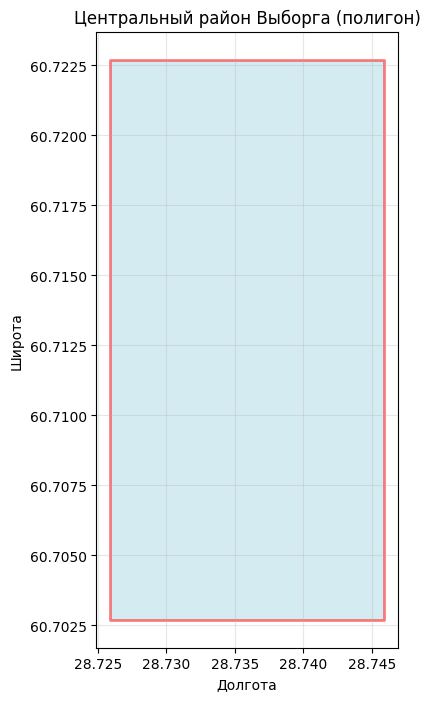

In [73]:
# 5. Визуализация
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
district.plot(ax=ax, edgecolor='red', facecolor='lightblue', alpha=0.5, linewidth=2)
ax.set_title('Центральный район Выборга (полигон)')
ax.set_xlabel('Долгота')
ax.set_ylabel('Широта')
ax.grid(True, alpha=0.3)
plt.show()


In [76]:
district_utm = district.to_crs('EPSG:32636')
gdf_utm = gdf.to_crs(district_utm.crs)

In [77]:
# Теперь CRS совпадают
print(f"CRS кофеен: {gdf_utm.crs}")
print(f"CRS района: {district_utm.crs}")


CRS кофеен: EPSG:32636
CRS района: EPSG:32636


In [ ]:
# Spatial join
inside = gpd.sjoin(gdf_utm, district_utm, predicate='within')

In [78]:
inside.head()

geometry amenity  \
element id                                                   
node    1963039383  POINT (267383.921 6738309.103)    cafe   
        1963039389  POINT (267405.371 6738300.895)    cafe   
        1963039404  POINT (267405.995 6738333.133)    cafe   
        2088154175  POINT (267062.716 6738480.163)    cafe   
        2092461521   POINT (267450.15 6738520.703)    cafe   

                             name_left           phone      opening_hours  \
element id                                                                  
node    1963039383             Камелот             NaN  Mo-Su 12:00-23:00   
        1963039389                Сова             NaN        10:00-24:00   
        1963039404              Europe             NaN                NaN   
        2088154175  Славянская трапеза  +7 81378 55267        12:00-24:00   
        2092461521             Игорика             NaN                NaN   

                    cuisine level  index_right         name_right  
element id                                                         
node    1963039383      NaN   NaN            0  Центральный район  
        1963039389  russian   NaN            0  Центральный район  
        1963039404      NaN   NaN            0  Центральный район  
        2088154175      NaN   NaN            0  Центральный район  
        2092461521      NaN   NaN            0  Центральный район

In [79]:
# 5. Результат
print(f"\n=== РЕЗУЛЬТАТ ===")
print(f"Кофеен в Центральном районе: {len(inside)} из {len(gdf)}")
print(f"Кофеен вне Центрального района: {len(gdf) - len(inside)}")


=== РЕЗУЛЬТАТ ===
Кофеен в Центральном районе: 39 из 92
Кофеен вне Центрального района: 53


In [80]:
# 6. Список
print(f"\nКофейни в Центральном районе:")
inside[['name_left']].head(10)



Кофейни в Центральном районе:


name_left
element id                            
node    1963039383             Камелот
        1963039389                Сова
        1963039404              Europe
        2088154175  Славянская трапеза
        2092461521             Игорика
        2092461557             Респект
        2092461560            Mr.Panda
        2417490653        Столовая № 1
        3324292696           Кафе Чача
        4146760027                Ника

## Часть 7. Сохранение данных

In [81]:
# Сохраняем в GeoJSON
gdf.to_file('../../data/vyborg_cafes.geojson', driver='GeoJSON')
print("Кофейни сохранены в vyborg_cafes.geojson")

Кофейни сохранены в vyborg_cafes.geojson


In [82]:
# Сохраняем в CSV
gdf_copy = gdf.copy()
gdf_copy['geometry_wkt'] = gdf_copy.geometry.to_wkt()
gdf_copy.drop(columns='geometry').to_csv('../../data/vyborg_cafes.csv', index=False)
print("Кофейни сохранены в vyborg_cafes.csv (с WKT-геометрией)")

Кофейни сохранены в vyborg_cafes.csv (с WKT-геометрией)


## Итоги

Мы научились:
1. Загружать геоданные из OpenStreetMap через OSMnx
2. Загружать все кофейни в радиусе от точки
3. Смотреть атрибуты объектов (названия, телефоны, кухню)
4. Вычислять расстояния до центра
5. Находить ближайшие объекты
6. Фильтровать объекты по расстоянию
7. Сохранять данные в GeoJSON и CSV

Это основа для геоаналитики — можно аналогично загружать рестораны, аптеки, школы, банки и т.д.